# Example - Selecting FRET populations

This notebook replicates the selecting FRET populations notebooks of FRETBursts in PhotonBursts.

> Old text in insets

> `Old code in # comments`
>
> `With equivalent new code below`

> *This notebook is part of smFRET burst analysis software [FRETBursts](https://opensmfs.github.io/FRETBursts/).*
> 
> In this notebook shows two methods to select FRET populations: size filtering and DCBS.
> For a complete tutorial on burst analysis see 
> [FRETBursts - us-ALEX smFRET burst analysis](us-ALEX_translation.ipynb)

This notebook shows how to select and plot data.

**See also** [Gates](GatesTutorial.ipynb) for an indepth description of how to select data in pySMFS.

The first step is to import PhotonBursts, we will also import some common libraries.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# from fretbursts import * # prefer explicit import
import fretbursts as smf

--------------------------------------------------------------
 You are running FRETBursts (version 1.0.1).

 If you use this software please cite the following paper:

   FRETBursts: An Open Source Toolkit for Analysis of Freely-Diffusing Single-Molecule FRET
   Ingargiola et al. (2016). http://dx.doi.org/10.1371/journal.pone.0160716 

--------------------------------------------------------------


## Get and process data

Enter the name of your file between the quotes after `full_fname = `

Then we will load the relevant data

In [2]:
full_fname = "HP3_TE300_SPC630.hdf5"

# d = loader.photon_hdf5(full_fname)
raw = smf.photonHDF5.load(full_fname)

# loader.alex_apply_period(d)
data = smf.photonHDF5.regularize_dets(raw)

And finally start to define analysis parameters

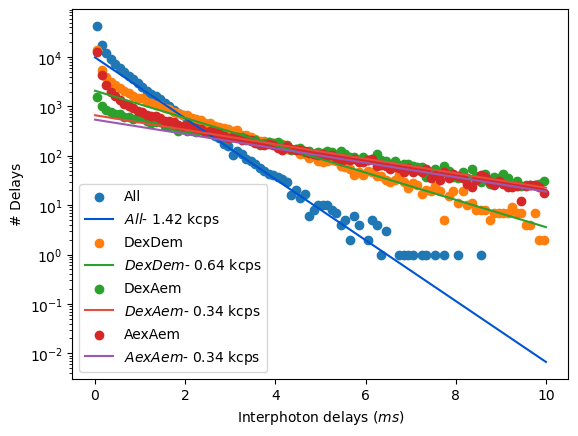

In [3]:
# d.calc_bg(bg.exp_fit, time_s=1000, tail_min_us=(800, 4000, 1500, 1000, 3000))
bg = smf.fretfactory.make_bg(data, period=60.0, tail_min=500e-6, func=smf.bg.exp_mlefit, auto_threshold=True)

smf.plot.hist_interphoton(data, bg['bg'], 0, streams=smf.fretfactory.ALEXdefaults.streams, 
                          labels=smf.fretfactory.ALEXdefaults.stream_labels, 
                          fit_streams_kwargs=smf.fretfactory.ALEXdefaults.stream_colors);

In [4]:
# d.burst_search(m=10, F=6.0)
acbs = smf.fretfactory.make_burst_search(bg['bg'], m=10, F=6.0, streams=smf.PhSel('0ex_1ex1em'))

# ds = d.select_bursts(select_bursts.size, add_naa=True, th1=40)
ac_gAll = smf.make_geq_gate(acbs['NphAll_bg'], 40.0)

## Filtering method

We can select the FRET population (S ~ 0.5) combining these two filters:

1. Filter out A-only: select bursts with counts during $D_{ex}$ > threshold
2. Filter out D-only: select bursts with counts in $A_{ex}A_{em}$ > threshold

In code, this becomes:

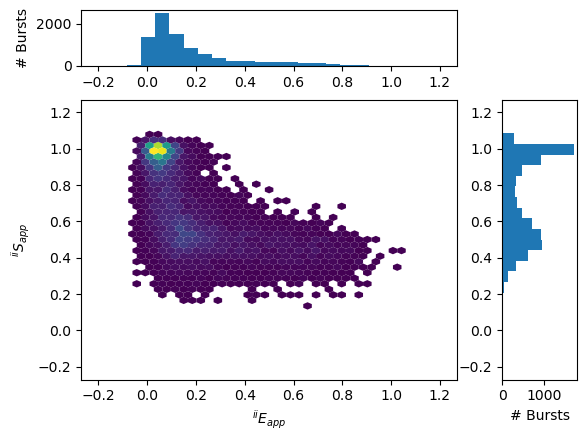

In [5]:
# ds_no_Aonly = ds.select_bursts(select_bursts.size, th1=30)
ac_gDactive = ac_gAll & smf.make_geq_gate(acbs['NphDex_bg'], 30.0)


# alex_jointplot(ds)
smf.plot.jointplot(data, acbs['E_bg'], acbs['S_bg'], gate=ac_gDactive, cfunc=smf.plot.hexbin, 
                   cplot_kwargs=smf.fretfactory.ALEXdefaults.hexbin,
                   hplot_kwargs={'bins':np.linspace(-0.2,1.2, 25)});

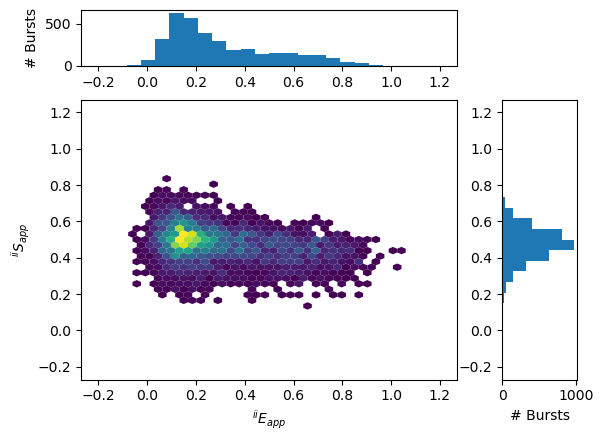

In [6]:
# ds_fret = ds_no_Aonly.select_bursts(select_bursts.naa, th1=30)
ac_gFRET = ac_gDactive & smf.make_geq_gate(acbs['NphAA_bg'], 30)

# alex_jointplot(ds_fret)
smf.plot.jointplot(data, acbs['E_bg'], acbs['S_bg'], gate=ac_gFRET, cfunc=smf.plot.hexbin, 
                   cplot_kwargs=smf.fretfactory.ALEXdefaults.hexbin,
                   hplot_kwargs={'bins':np.linspace(-0.2,1.2, 25)});

### DCBS Method

With Dual-channel Burst Search (DCBS),
we define bursts as the intersection of a burst search performed on $D_{ex}$ stream and 
one performed on $A_{ex}A_{em}$ stream (see ([Nir et al. JPC 2006](https://doi.org/10.1021/jp063483n))).

In this way we filter D-only and A-only bursts,
but also we reduce the burst duration of FRET bursts to the portion where
$D_{ex}$ and $A_{ex}A_{em}$ both give signal. This property allows filtering 
acceptor photo-blinking, that causes part of a burst to appear as D-only.

To perform DCBS in FRETBursts we use:

In [7]:
# d_fret_2 = bext.burst_search_and_gate(d)
dcbs1 = smf.fretfactory.make_burst_search(bg['bg'], m=10, F=6.0, streams=(smf.PhSel('0ex'), smf.PhSel('1ex1em')))

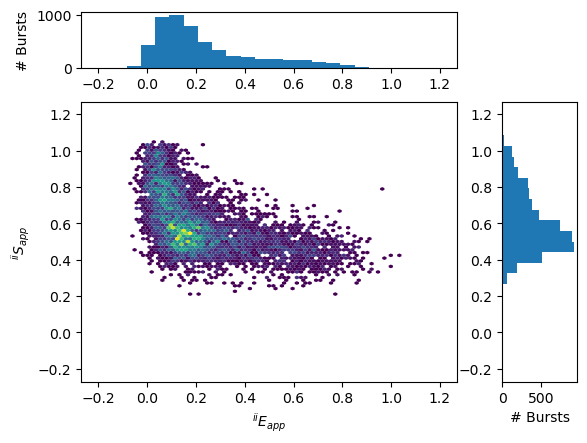

In [8]:
# ds_fret_2 = d_fret_2.select_bursts(select_bursts.size, th1=30)
d1_gFRET = smf.make_geq_gate(dcbs1['NphDex_bg'], 30)

# alex_jointplot(ds_fret_2);
smf.plot.jointplot(data, dcbs1['E_bg'], dcbs1['S_bg'], gate=d1_gFRET, cfunc=smf.plot.hexbin, 
                   cplot_kwargs={'gridsize':80, 'extent':(-0.2,1.2,-0.2,1.2), 
                                 'mincnt':1, 'edgecolor':'none', 'linewidth':0.2},
                   hplot_kwargs={'bins':np.linspace(-0.2,1.2, 25)});

> The function [bext.burst_search_and_gate()](https://fretbursts.readthedocs.io/en/latest/plugins.html?highlight=burst_search_and#fretbursts.burstlib_ext.burst_search_and_gate)
> performs two burst searches on the photon streams defined by `ph_sel1` and `ph_sel2` arguments
> (by default `ph_sel1=Ph_sel(Dex='DAem')` and `ph_sel2=Ph_sel(Aex='Aem')`, i.e. $D_{ex}$ and $A_{ex}A_{em}$).
> Then, it takes the "intersection in time" (and-gate) for the two sets of bursts.

> `burst_search_and_gate` accepts the same 
> *m*, *F*, and *min_rate_cps* arguments as [Data.burst_search()](https://fretbursts.readthedocs.io/en/latest/data_class.html#fretbursts.burstlib.Data.burst_search).
> It is also possible to use different burst search parameters for the two
> burst searches:

In `smf.fretfactory.make_burst_search()` we can perform any number of burst searches and take their intersection.
This is done by specifying multiple photon streams in the ``streams`` keyword argument.
Other arguments can also be specified as sequences of values to adjust the value per burst search.
The function automatically converts all single value arguments into arrays of length in streams.

In [9]:
# d_fret_22 = bext.burst_search_and_gate(d, m=(8, 10), F=(5, 12))
dcbs2 = smf.fretfactory.make_burst_search(bg['bg'], m=(8, 10), F=(5.0, 12.0), streams=(smf.PhSel('0ex'), smf.PhSel('1ex1em')))

Before plotting we still need to select bursts by size:

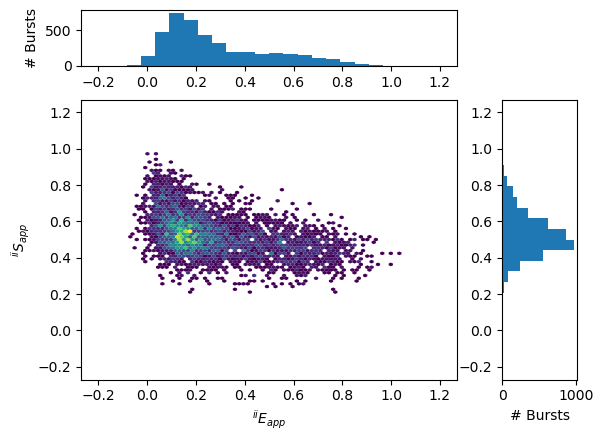

In [10]:
# ds_fret_22 = d_fret_22.select_bursts(select_bursts.size, th1=30)
d2_gFRET = smf.make_geq_gate(dcbs2['NphDex_bg'], 30)

# alex_jointplot(ds_fret_22);
smf.plot.jointplot(data, dcbs2['E_bg'], dcbs2['S_bg'], gate=d2_gFRET, cfunc=smf.plot.hexbin, 
                   cplot_kwargs={'gridsize':80, 'extent':(-0.2,1.2,-0.2,1.2), 
                                 'mincnt':1, 'edgecolor':'none', 'linewidth':0.2},
                   hplot_kwargs={'bins':np.linspace(-0.2,1.2, 25)});